<a href="https://colab.research.google.com/github/vivilchesm-rgb/MineriaEvaluacion/blob/Kevin-Castro/PeliculasPresupuestos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Importación y Carga de dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importamos las librerias necesarias para realizar los diversos analisis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Cargamos el dataset
df = pd.read_csv("/content/expensive_movie.csv")

In [ ]:
#Revisamos la cantidad de filas y columnas del dataset
df.shape

(8121, 17)

In [ ]:
#Visualizamos las primeras filas para obtener información de estas
df.head()

,ID,Title,Original_Language,Release_Date,Popularity,Vote_Average,Vote_Count,Runtime,Budget,Revenue,Status,Tagline,Overview,Genres,Production_Companies,Production_Countries,Spoken_Languages
0,969681,Spider-Man: Brand New Day,en,2026-07-29,81.5967,0.000,0,0,0,0,Post Production,A brand new day starts now.,Four years have passed since the events of No ...,"Science Fiction, Action, Adventure","Marvel Studios, Columbia Pictures, Pascal Pict...",United States of America,English
1,1242898,Predator: Badlands,en,2025-11-05,78.4384,7.704,2424,107,105000000,184500000,Released,First hunt. Last chance.,"Cast out from his clan, a young Predator finds...","Action, Science Fiction, Adventure","20th Century Studios, Lawrence Gordon Producti...",United States of America,"French, English"
2,11375,Hollywood Homicide,en,2003-06-09,62.2209,5.238,686,116,75000000,51142659,Released,They're two cops with one shot at solving a mu...,"Joe Gavilan and his new partner K. C. Calden, ...","Action, Adventure, Comedy, Thriller",Revolution Studios,United States of America,English
3,7451,xXx,en,2002-08-09,61.1958,5.980,4821,124,70000000,277448382,Released,A new breed of secret agent.,Xander Cage is your standard adrenaline junkie...,"Action, Adventure, Thriller, Crime, Drama",Revolution Studios,United States of America,"Czech, English, German, Spanish, Russian"
4,458576,Monster Hunter,en,2020-12-03,52.1623,6.526,3508,103,60000000,42145959,Released,"Behind our world, there is another.",A portal transports Cpt. Artemis and an elite ...,"Action, Fantasy, Adventure","Capcom, Constantin Film, Tencent Pictures, TOH...","China, Germany, Japan, Canada",English


##2. Verificación de Datos Inicial

In [ ]:
#Verificamos los tipos de datos con los que estamos tratando
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8121 entries, 0 to 8120
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    8121 non-null   int64  
 1   Title                 8121 non-null   object 
 2   Original_Language     8121 non-null   object 
 3   Release_Date          7760 non-null   object 
 4   Popularity            8121 non-null   float64
 5   Vote_Average          8121 non-null   float64
 6   Vote_Count            8121 non-null   int64  
 7   Runtime               8121 non-null   int64  
 8   Budget                8121 non-null   int64  
 9   Revenue               8121 non-null   int64  
 10  Status                8121 non-null   object 
 11  Tagline               3425 non-null   object 
 12  Overview              7734 non-null   object 
 13  Genres                8118 non-null   object 
 14  Production_Companies  6594 non-null   object 
 15  Production_Countries 

###Diccionario de Datos (Mapeo de Columnas)
Hacer este mapeo o diccionario de datos es fundamental para entender bien de qué trata nuestro proyecto. Nos sirve para ponernos de acuerdo en qué significa cada columna y saber si estamos trabajando con números o categorías.

| Nombre de Columna | Descripción | Variable Estadística | Tipo Informático (Dtype) |
| :--- | :--- | :--- | :--- |
| `ID` | Identificador único de la película. | Numérica (ID) | `int64` |
| `Title` | Nombre oficial de la producción. | Categórica Nominal | `object (string)` |
| `Original_Language` | Código del idioma original (ej. 'en', 'zh'). | Categórica Nominal | `object (string)` |
| `Release_Date` | Fecha de estreno oficial. | Categórica (Temporal) | `object (datetime)` |
| `Popularity` | Índice de tendencia/vistas en la base de datos. | Numérica Continua | `float64` |
| `Vote_Average` | Calificación promedio otorgada por usuarios. | Numérica Continua | `float64` |
| `Vote_Count` | Cantidad total de votos registrados. | Numérica Discreta | `int64` |
| `Runtime` | Duración de la película en minutos. | Numérica Discreta | `int64` |
| `Budget` | Presupuesto total de producción en USD. | Numérica Continua | `int64 / float64` |
| `Revenue` | Ingresos totales recaudados en taquilla. | Numérica Continua | `int64 / float64` |
| `Status` | Estado de la película (Released, Post Production). | Categórica Nominal | `object (string)` |
| `Genres` | Lista de géneros asociados a la cinta. | Categórica (Multivalor) | `object (string)` |

---

In [ ]:
#Identificar valores nulos en el dataset
print("Conteo de valores nulos por columna:")
print(df.isnull().sum())

Conteo de valores nulos por columna:
ID                         0
Title                      0
Original_Language          0
Release_Date             361
Popularity                 0
Vote_Average               0
Vote_Count                 0
Runtime                    0
Budget                     0
Revenue                    0
Status                     0
Tagline                 4696
Overview                 387
Genres                     3
Production_Companies    1527
Production_Countries    1046
Spoken_Languages         876
dtype: int64


##3. Limpieza de datos para el analisis

In [ ]:
#Eliminamos registros incompletos para asegurar la calidad del análisis
df_limpio = df[(df['Budget'] > 0) & (df['Revenue'] > 0)].copy()

In [ ]:
#Eliminar filas con valores nulos
df_limpio = df_limpio.dropna()
print(f"\nRegistros originales: {len(df)}")
print(f"Registros después de la limpieza: {len(df_limpio)}")


Registros originales: 8121
Registros después de la limpieza: 833


In [ ]:
#Cargamos un nuevo dataset procesado con columnas limpias
df.to_csv("expensive_movie_procesado.csv", index=False)

## Análisis Profundo: Calificaciones, Estacionalidad y Estructura

### 1. Distribución de Calificaciones (Vote Average)
Exploramos cómo se distribuyen las puntuaciones de los usuarios para entender la calidad percibida de las películas en el dataset.

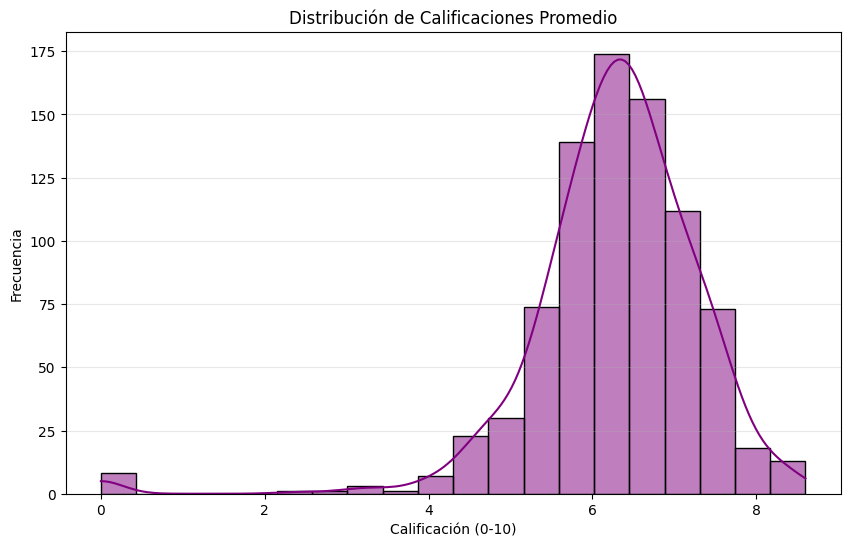

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_limpio['Vote_Average'], bins=20, kde=True, color='purple')
plt.title('Distribución de Calificaciones Promedio')
plt.xlabel('Calificación (0-10)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 2. Estacionalidad: Lanzamientos por Mes
Identificamos qué meses son los preferidos para los estrenos de películas de alto presupuesto.

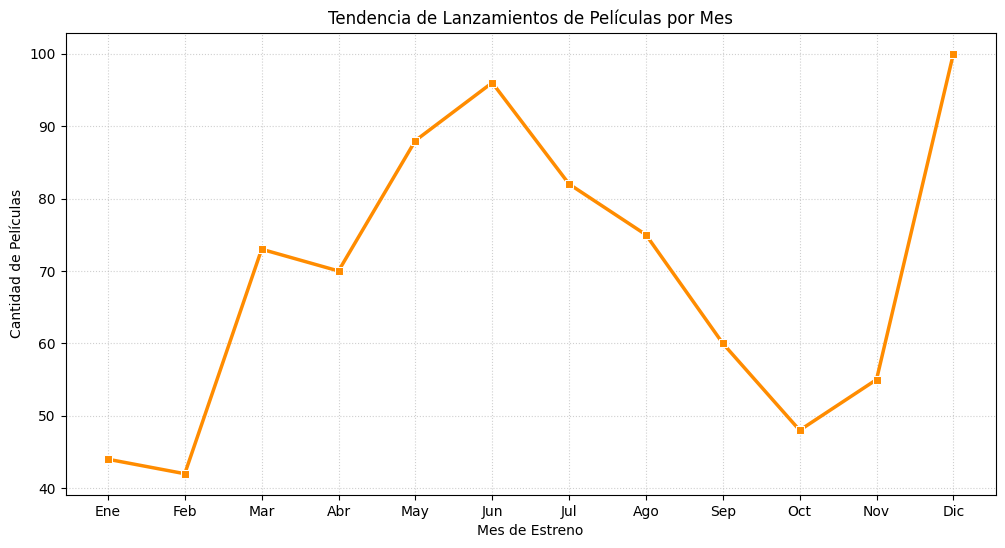

In [ ]:
df_limpio['Month'] = df_limpio['Release_Date'].dt.month
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

lanzamientos_mes = df_limpio['Month'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=meses_nombres, y=lanzamientos_mes.values, marker='s', color='darkorange', linewidth=2.5)
plt.title('Tendencia de Lanzamientos de Películas por Mes')
plt.xlabel('Mes de Estreno')
plt.ylabel('Cantidad de Películas')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 3. Relación Presupuesto vs Duración
¿Las películas con mayor presupuesto suelen durar más minutos?

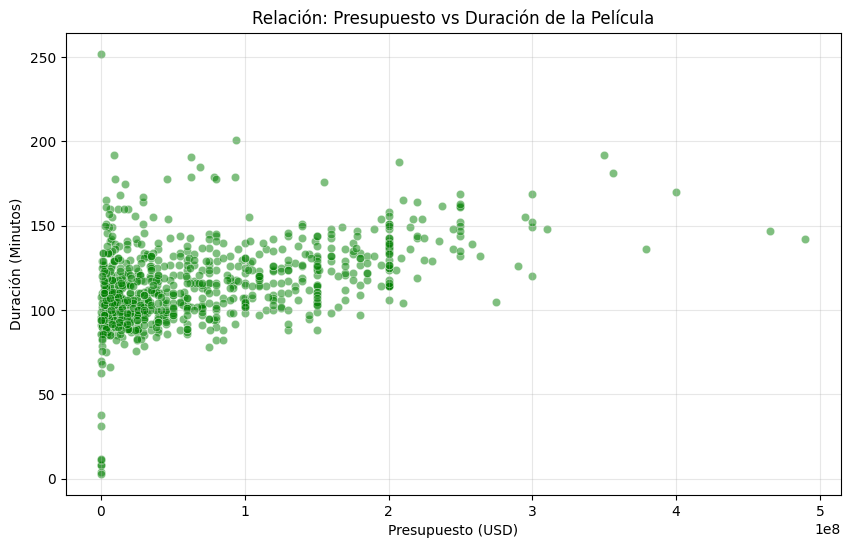

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_limpio, x='Budget', y='Runtime', alpha=0.5, color='green')
plt.title('Relación: Presupuesto vs Duración de la Película')
plt.xlabel('Presupuesto (USD)')
plt.ylabel('Duración (Minutos)')
plt.grid(True, alpha=0.3)
plt.show()

git config --global user.email ke.castrob@duocuc.cl
git config --global user.name keandres12